In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, ReduceLROnPlateau
from tensorflow import keras
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Activation, Dropout
from tensorflow.keras.models import Sequential
from src.metrics import metrics
from src.load_data import get_dataset, prepare_df
from src.pipeline import get_preprocessor
from sklearn.model_selection import train_test_split
import tensorflow as tf
import os
seed = 42
tf.keras.utils.set_random_seed(seed)
tf.config.experimental.enable_op_determinism()
os.environ["PYTHONHASHSEED"] = str(seed)

In [2]:
df = get_dataset()

In [3]:
X_train_val, X_test, y_train_val, y_test = prepare_df(df)

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, random_state=42, stratify=y_train_val, shuffle=True, test_size=0.2)

In [5]:
preprocessor = get_preprocessor()

In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(4507, 19)
(4507,)
(1127, 19)
(1127,)
(1409, 19)
(1409,)


In [7]:
early_stop = EarlyStopping(
    monitor="val_recall",
    patience=5,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

In [8]:
reducelr = ReduceLROnPlateau(
    min_lr=1e-7,
    monitor="val_recall",
    factor=0.5,
    patience=3
)

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [10]:
def build_model(hp):
    model = Sequential()
    # Adding Input layer to the model
    model.add(Input(shape=X_train_processed.shape[1:]))

    # Tuning dense layers
    num_dense_layers = hp.Int("num_layers", min_value=2, max_value=7, step=1)
    for i in range(num_dense_layers):
        model.add(
            Dense(
                units=hp.Int(f"neuron_units_{i}", min_value=16, max_value=256, step=32)
            )
        )

        model.add(BatchNormalization())

        model.add(
            Activation(
                hp.Choice(f"activation_{i}", values=["relu", "selu", "elu", "tanh"])
            )
        )

        if hp.Boolean(f"dropout_{i}"):
            model.add(
                Dropout(
                    hp.Float(
                        f"dropout_rate_{i}", min_value=0.1, max_value=0.5, step=0.1
                    )
                )
            )

    model.add(Dense(1, activation="sigmoid"))

    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-4, 1e-5])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["recall", "accuracy"]
    )

    return model

In [11]:
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_recall", direction="max"),
    max_epochs=10,
    factor=3,
    seed=42,
    directory = "tuner_results",
    project_name = "telco_ann_search"
)

Reloading Tuner from tuner_results/telco_ann_search/tuner0.json


In [12]:
tuner.search(
    X_train_processed,
    y_train,
    validation_data=[X_val_processed, y_val],
    callbacks=[early_stop, reducelr]
)

In [13]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_hp.values

2026-08-21 23:13:47.485003: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-08-21 23:13:47.485039: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-08-21 23:13:47.485043: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-08-21 23:13:47.485063: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-21 23:13:47.485076: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/yugamdeepgoyal/my_gpu/tf_env/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variab

{'num_layers': 3,
 'neuron_units_0': 240,
 'activation_0': 'tanh',
 'dropout_0': False,
 'neuron_units_1': 16,
 'activation_1': 'relu',
 'dropout_1': True,
 'learning_rate': 1e-05,
 'dropout_rate_1': 0.2,
 'neuron_units_2': 176,
 'activation_2': 'tanh',
 'dropout_2': True,
 'neuron_units_3': 16,
 'activation_3': 'elu',
 'dropout_3': False,
 'neuron_units_4': 240,
 'activation_4': 'tanh',
 'dropout_4': True,
 'dropout_rate_0': 0.1,
 'neuron_units_5': 240,
 'activation_5': 'elu',
 'dropout_5': True,
 'tuner/epochs': 2,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 2,
 'tuner/round': 0,
 'dropout_rate_2': 0.1}

In [14]:
final_model = tuner.hypermodel.build(best_hp)

In [15]:
history = final_model.fit(
    X_train_processed,
    y_train,
    epochs=100,
    validation_data=[X_val_processed, y_val],
    callbacks=[early_stop, reducelr],
)

Epoch 1/100


2026-08-21 23:13:48.357975: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.5389 - loss: 0.7561 - recall: 0.5201 - val_accuracy: 0.6211 - val_loss: 0.6675 - val_recall: 0.3512 - learning_rate: 1.0000e-05
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.5940 - loss: 0.6989 - recall: 0.6104 - val_accuracy: 0.6912 - val_loss: 0.6280 - val_recall: 0.6154 - learning_rate: 1.0000e-05
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6259 - loss: 0.6640 - recall: 0.6237 - val_accuracy: 0.6983 - val_loss: 0.6081 - val_recall: 0.6990 - learning_rate: 1.0000e-05
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6568 - loss: 0.6385 - recall: 0.6773 - val_accuracy: 0.7001 - val_loss: 0.5962 - val_recall: 0.7224 - learning_rate: 1.0000e-05
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6747 - loss: 0.6221 - recall: 0.6915 - val_accuracy: 0.7134 - val_loss: 0.5850 - val_recall: 0.7525 - learning_rate: 1.0000e-05
Epoch 6/100
141/141 ━━━━━━━━━━━━

In [16]:
test_loss, test_f1, test_acc = final_model.evaluate(X_test_processed, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7111 - loss: 0.5892 - recall: 0.7727


In [17]:
test_acc

0.7111426591873169

In [18]:
test_loss

0.5891737341880798

In [19]:
test_f1

0.7727272510528564

In [20]:
y_pred_proba = final_model.predict(X_test_processed)
y_pred = (y_pred_proba >= 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Accuracy score: 0.7111426543647977
recall score: 0.7727272727272727
precision score: 0.47299509001636664
f1 score: 0.5868020304568528
ROC-AUC score: 0.7975328734919527
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.69      0.78      1035
           1       0.47      0.77      0.59       374

    accuracy                           0.71      1409
   macro avg       0.68      0.73      0.68      1409
weighted avg       0.78      0.71      0.73      1409



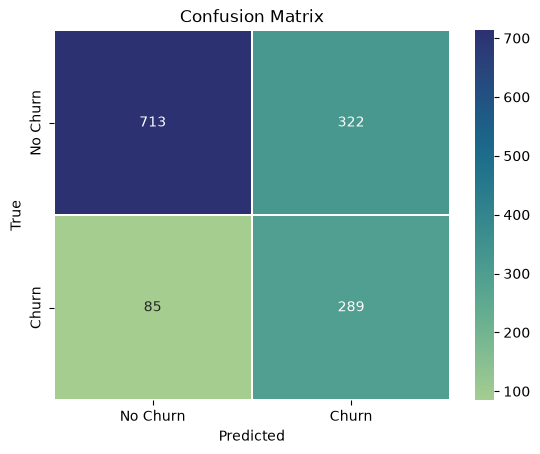

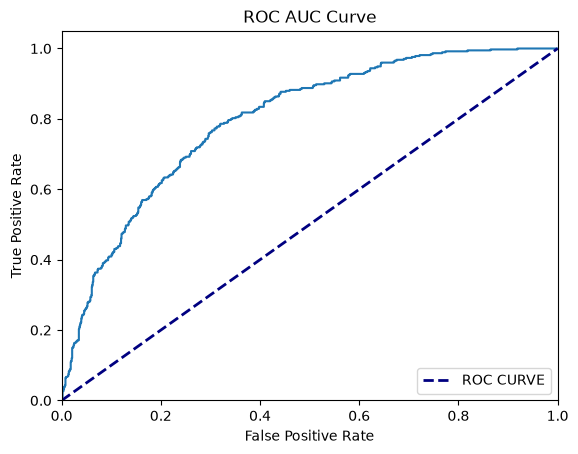

In [21]:
metrics(y_test, y_pred, y_pred_proba)

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy score: 0.7246505435988463
recall score: 0.7575250836120402
precision score: 0.4878836833602585
f1 score: 0.5935145758270554
ROC-AUC score: 0.8040658785097613
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      3311
           1       0.49      0.76      0.59      1196

    accuracy                           0.72      4507
   macro avg       0.69      0.74      0.69      4507
weighted avg       0.78      0.72      0.74      4507



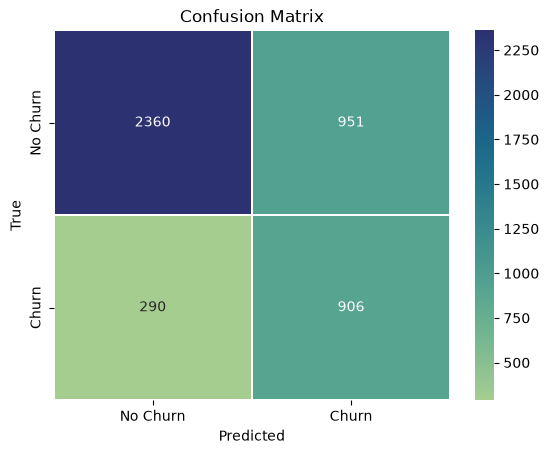

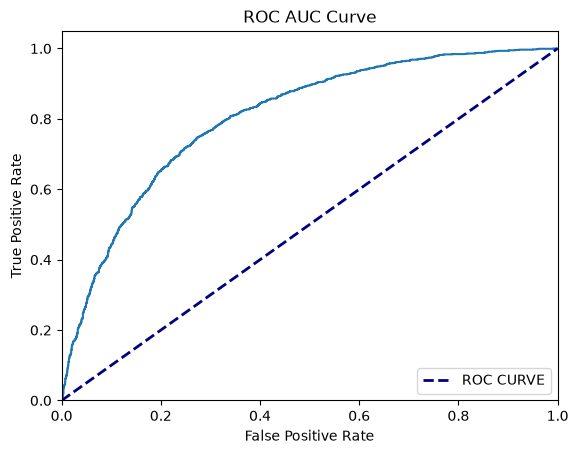

In [22]:
y_train_pred_proba = final_model.predict(X_train_processed)
y_train_pred = (y_train_pred_proba >= 0.5).astype(int)
metrics(y_train, y_train_pred, y_train_pred_proba)

In [23]:
final_model.save("models/ann.keras")

In [24]:
loaded_model = tf.keras.models.load_model("models/ann.keras")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy score: 0.7111426543647977
recall score: 0.7727272727272727
precision score: 0.47299509001636664
f1 score: 0.5868020304568528
ROC-AUC score: 0.7975328734919527
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.69      0.78      1035
           1       0.47      0.77      0.59       374

    accuracy                           0.71      1409
   macro avg       0.68      0.73      0.68      1409
weighted avg       0.78      0.71      0.73      1409



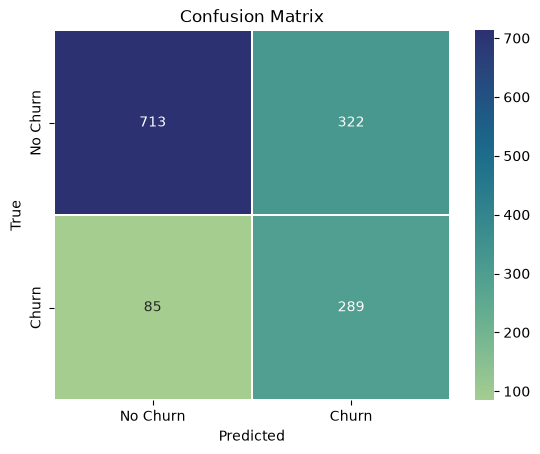

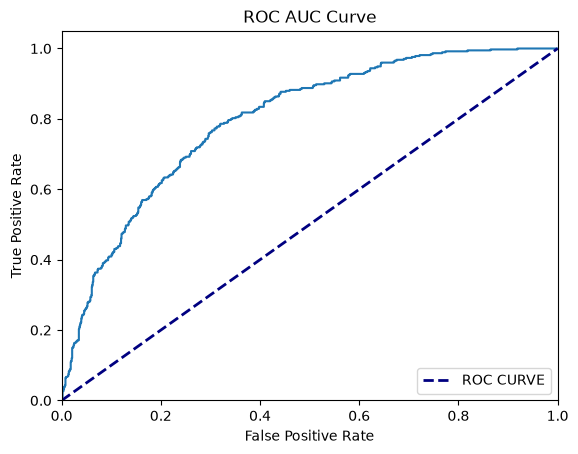

In [25]:
y_pred_proba1 = loaded_model.predict(X_test_processed)
y_pred1 = (y_pred_proba1 > 0.5).astype(int)
metrics(y_test, y_pred1, y_pred_proba1)